#SPML Base Task

#Phase 1 : requirred imports


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

#Data import , train/test splitting

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(root='./data', train=True,
                                    download=True, transform=transform)

test_data = datasets.FashionMNIST(root='./data', train=False,
                                   download=True, transform=transform)

train_size = int(0.8 * len(train_data))
val_size   = len(train_data) - train_size

train_set, val_set = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train size : {train_size}")
print(f"Val size   : {val_size}")
print(f"Test size  : {len(test_data)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]

Train size : 48000
Val size   : 12000
Test size  : 10000


#model architecture


In [4]:
class FashionModel(nn.Module):
    def __init__(self):
        super(FashionModel, self).__init__()

        self.stem = nn.Linear(784, 16)

        self.branchA_1 = nn.Linear(16, 8)
        self.branchA_2 = nn.Linear(8, 8)

        self.branchB_1 = nn.Linear(16, 12)
        self.branchB_2 = nn.Linear(12, 8)

        self.output = nn.Linear(16, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)

        x = self.relu(self.stem(x))

        a1 = self.relu(self.branchA_1(x))
        a2 = self.relu(self.branchA_2(a1))

        b1 = self.relu(self.branchB_1(x))
        b2 = self.relu(self.branchB_2(b1))

        skip = a1 + a2

        combined = torch.cat([skip, b2], dim=1)

        out = self.output(combined)
        return out


model = FashionModel()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

FashionModel(
  (stem): Linear(in_features=784, out_features=16, bias=True)
  (branchA_1): Linear(in_features=16, out_features=8, bias=True)
  (branchA_2): Linear(in_features=8, out_features=8, bias=True)
  (branchB_1): Linear(in_features=16, out_features=12, bias=True)
  (branchB_2): Linear(in_features=12, out_features=8, bias=True)
  (output): Linear(in_features=16, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 13,246


#Traing Setup

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: cpu


#Training Loop

In [6]:
EPOCHS = 20

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):

    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1:2d}/{EPOCHS}] "
          f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% "
          f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

print("\nTraining Complete!")

Epoch [ 1/20] | Train Loss: 0.7364 | Train Acc: 72.92% | Val Loss: 0.5037 | Val Acc: 82.33%
Epoch [ 2/20] | Train Loss: 0.4680 | Train Acc: 83.17% | Val Loss: 0.4478 | Val Acc: 83.97%
Epoch [ 3/20] | Train Loss: 0.4301 | Train Acc: 84.59% | Val Loss: 0.4289 | Val Acc: 84.75%
Epoch [ 4/20] | Train Loss: 0.4101 | Train Acc: 85.40% | Val Loss: 0.4236 | Val Acc: 84.65%
Epoch [ 5/20] | Train Loss: 0.3934 | Train Acc: 86.05% | Val Loss: 0.4177 | Val Acc: 85.34%
Epoch [ 6/20] | Train Loss: 0.3836 | Train Acc: 86.25% | Val Loss: 0.4122 | Val Acc: 85.12%
Epoch [ 7/20] | Train Loss: 0.3755 | Train Acc: 86.49% | Val Loss: 0.4075 | Val Acc: 85.63%
Epoch [ 8/20] | Train Loss: 0.3667 | Train Acc: 86.84% | Val Loss: 0.3912 | Val Acc: 85.97%
Epoch [ 9/20] | Train Loss: 0.3604 | Train Acc: 87.03% | Val Loss: 0.3930 | Val Acc: 86.01%
Epoch [10/20] | Train Loss: 0.3562 | Train Acc: 87.15% | Val Loss: 0.3935 | Val Acc: 86.04%
Epoch [11/20] | Train Loss: 0.3500 | Train Acc: 87.38% | Val Loss: 0.3845 | Val 

#Training Plots

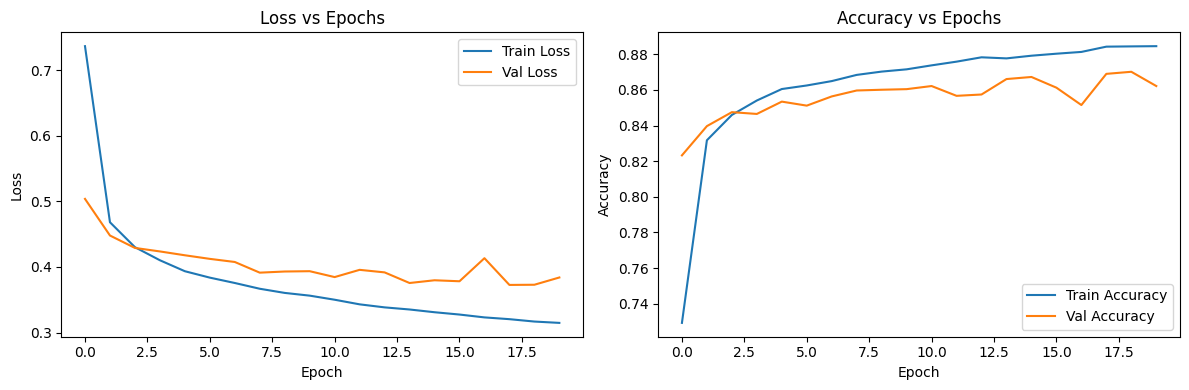

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss vs Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs, label='Val Accuracy')
ax2.set_title('Accuracy vs Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('Accuracy and loss plots.png', dpi=150)
plt.show()

In [ ]:
with open('saved model weights.pkl', 'wb') as f:
    pickle.dump(model.state_dict(), f)

print("Weights saved!")

Weights saved!


#My Predictions

In [9]:
model.eval()
all_preds = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

df = pd.DataFrame({
    'Id': range(len(all_preds)),
    'Category': all_preds
})

df.to_csv('submission.csv', index=False)
print("submission.csv saved!")
print(df.head())

submission.csv saved!
   Id  Category
0   0         9
1   1         2
2   2         1
3   3         1
4   4         6
